In [1]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import seaborn as sns

mnth_df = pd.read_csv(r"..\Uncleaned dataset\Monthly_Statistics_Raw 2015-2024.csv")

print(mnth_df.head())
print(mnth_df.info())
print(mnth_df.describe())

   Year     Month  Fatal  Non_Fatal_Injury  Damage_to_Property  Grand_Total
0  2015   January     46              1377                5491         6914
1  2015  February     52              1414                5895         7361
2  2015     March     42              1652                6448         8142
3  2015     April     35              1440                5838         7313
4  2015       May     43              1427                6352         7822
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Year                129 non-null    int64 
 1   Month               129 non-null    object
 2   Fatal               129 non-null    int64 
 3   Non_Fatal_Injury    129 non-null    int64 
 4   Damage_to_Property  129 non-null    int64 
 5   Grand_Total         129 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 6.2+ KB
None
 

In [2]:
def unique(dataset):
    print(dataset.nunique())
    print(dataset.unique())

unique(mnth_df['Year'])
unique(mnth_df['Month'])

10
[2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]
13
['January' 'February' 'March' 'April' 'May' 'June' 'July' 'August'
 'September' 'October' 'November' 'December' 'Grand Total']


In [3]:
mnth_df = mnth_df[mnth_df['Month'] != 'Grand Total']
unique(mnth_df['Year'])
unique(mnth_df['Month'])

10
[2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]
12
['January' 'February' 'March' 'April' 'May' 'June' 'July' 'August'
 'September' 'October' 'November' 'December']


In [4]:
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}

mnth_df['year'] = mnth_df['Year']
mnth_df['day'] = 1
mnth_df['month'] = mnth_df['Month'].map(month_map)
mnth_df['date'] = pd.to_datetime(mnth_df[['year','month','day']])
del mnth_df['Year']
mnth_df['month'] = mnth_df['month'].astype('Int64')
mnth_df = mnth_df.sort_values('date').reset_index(drop=True)
unique(mnth_df['month'])

12
<IntegerArray>
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Length: 12, dtype: Int64


In [5]:
mnth_df['month'].value_counts()

month
1     10
2     10
3     10
4     10
5     10
6     10
7     10
8     10
9     10
10    10
11    10
12    10
Name: count, dtype: Int64

array([[<Axes: title={'center': 'Fatal'}>,
        <Axes: title={'center': 'Non_Fatal_Injury'}>,
        <Axes: title={'center': 'Damage_to_Property'}>],
       [<Axes: title={'center': 'Grand_Total'}>,
        <Axes: title={'center': 'year'}>,
        <Axes: title={'center': 'day'}>],
       [<Axes: title={'center': 'month'}>,
        <Axes: title={'center': 'date'}>, <Axes: >]], dtype=object)

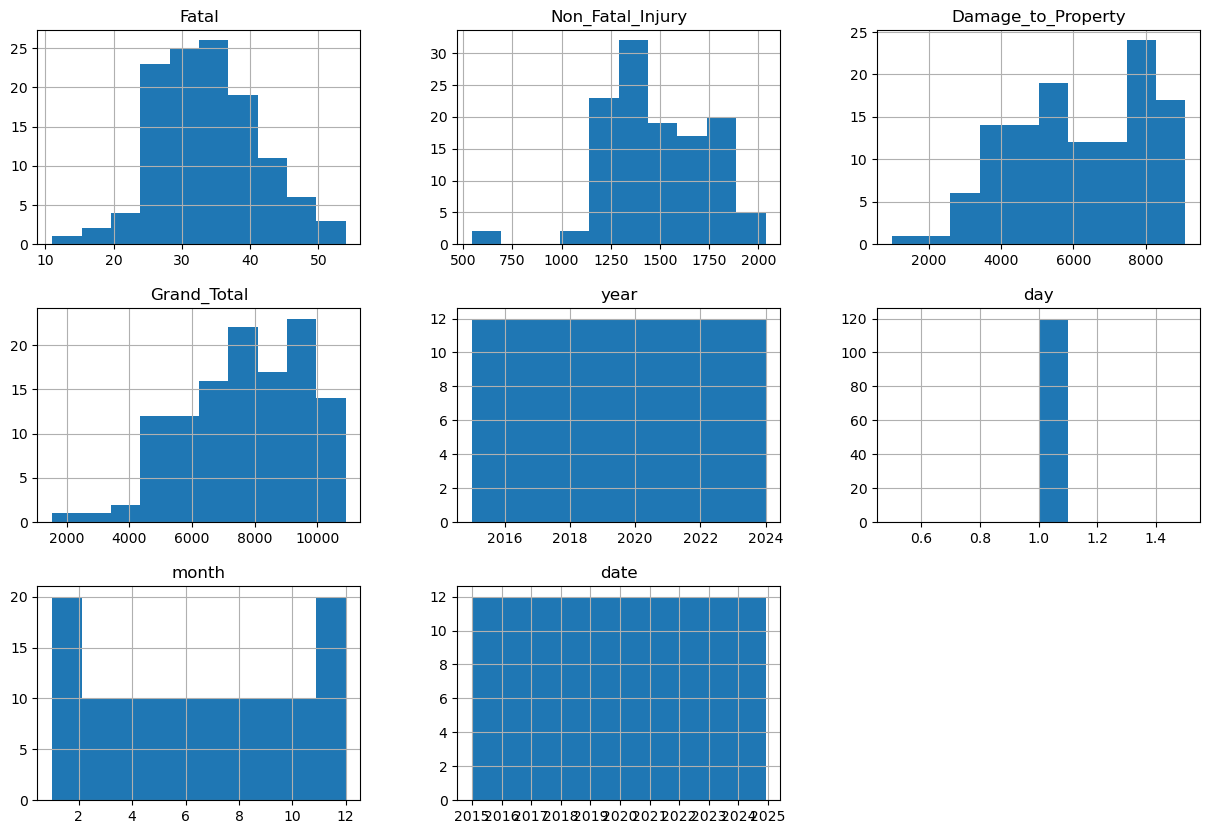

In [6]:
mnth_df.hist(bins=10,figsize=(15,10))

In [7]:
def skew_check(dataset,val):
    print("Skewness Check:")
    for col in val:
        skew = dataset[col].skew()
        print(f"{col:10s}: {skew:6.2f} {'TRANSFORM' if abs(skew) > 1 else 'OK'}")

skew_check(mnth_df, ['Fatal','Non_Fatal_Injury','Damage_to_Property'])

Skewness Check:
Fatal     :   0.15 OK
Non_Fatal_Injury:  -0.38 OK
Damage_to_Property:  -0.30 OK


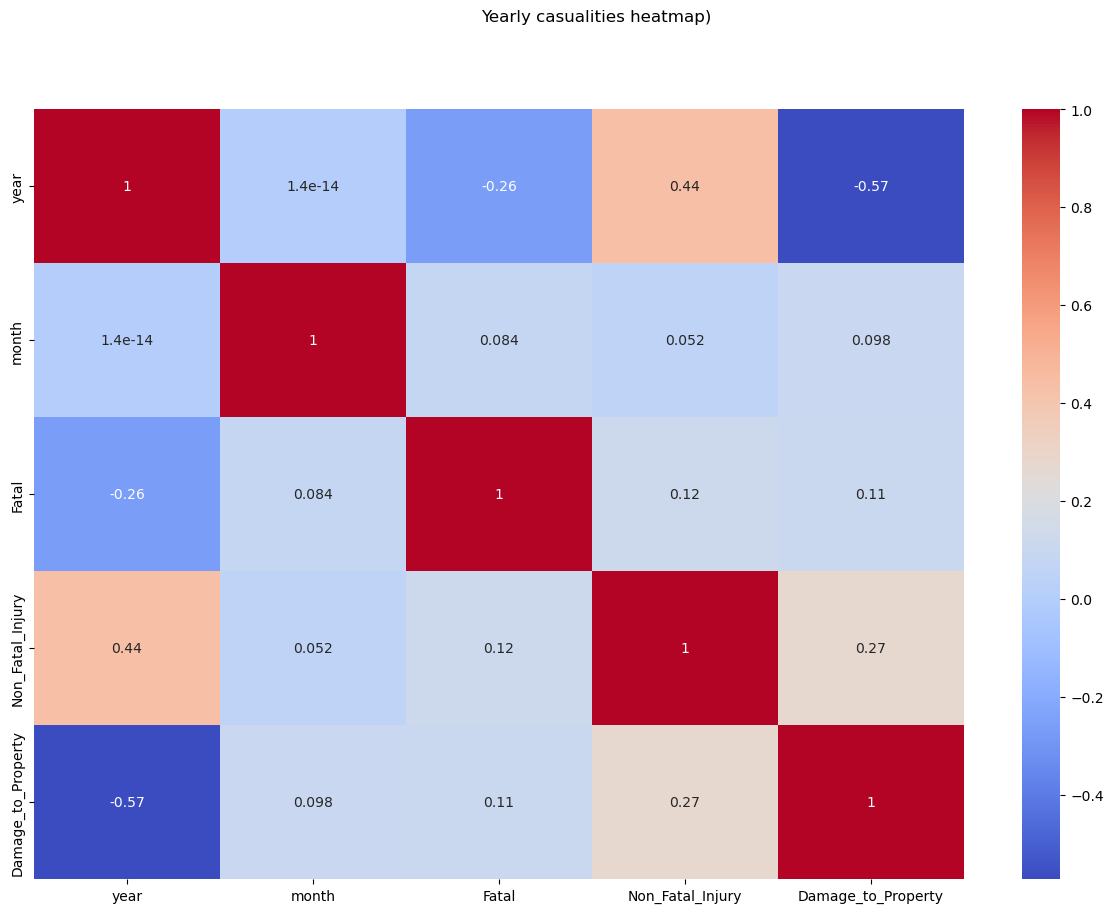

In [8]:
plt.figure(figsize = (15,10))
sns.heatmap(mnth_df[['year','month','Fatal','Non_Fatal_Injury','Damage_to_Property']].corr(), annot=True,cmap='coolwarm')
plt.suptitle('Yearly casualities heatmap)')
plt.savefig('Yearly casualities heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

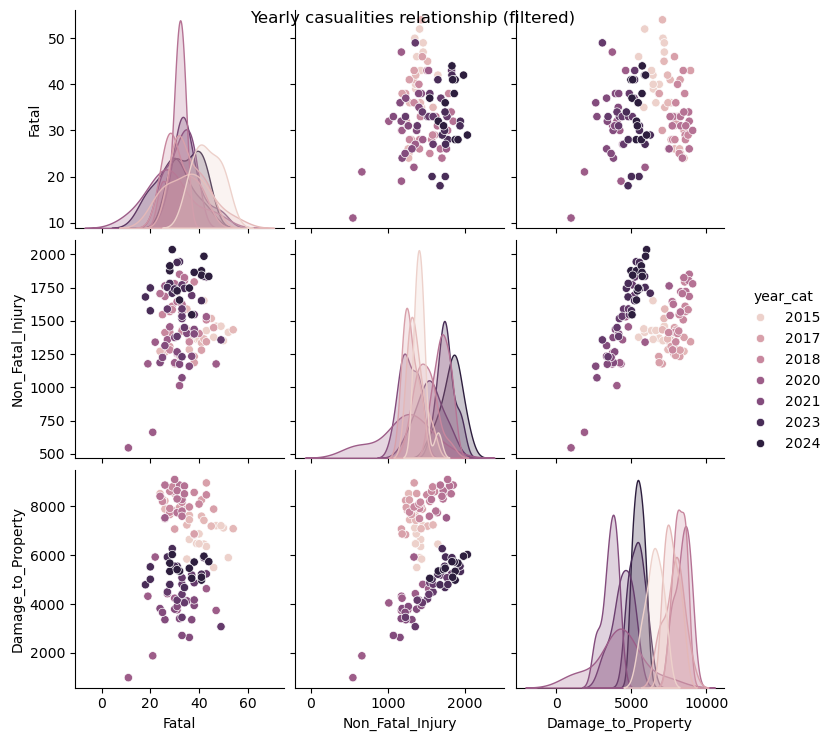

In [9]:
mnth_df['year_cat'] = mnth_df['year']
sns.pairplot(mnth_df[['Fatal','Non_Fatal_Injury','Damage_to_Property'] + ['year_cat']],diag_kind = 'kde', hue = 'year_cat')
plt.suptitle('Yearly casualities relationship (filtered)')
plt.savefig('Yearly casualities relationship (filtered).png', dpi=300, bbox_inches='tight')
plt.show()

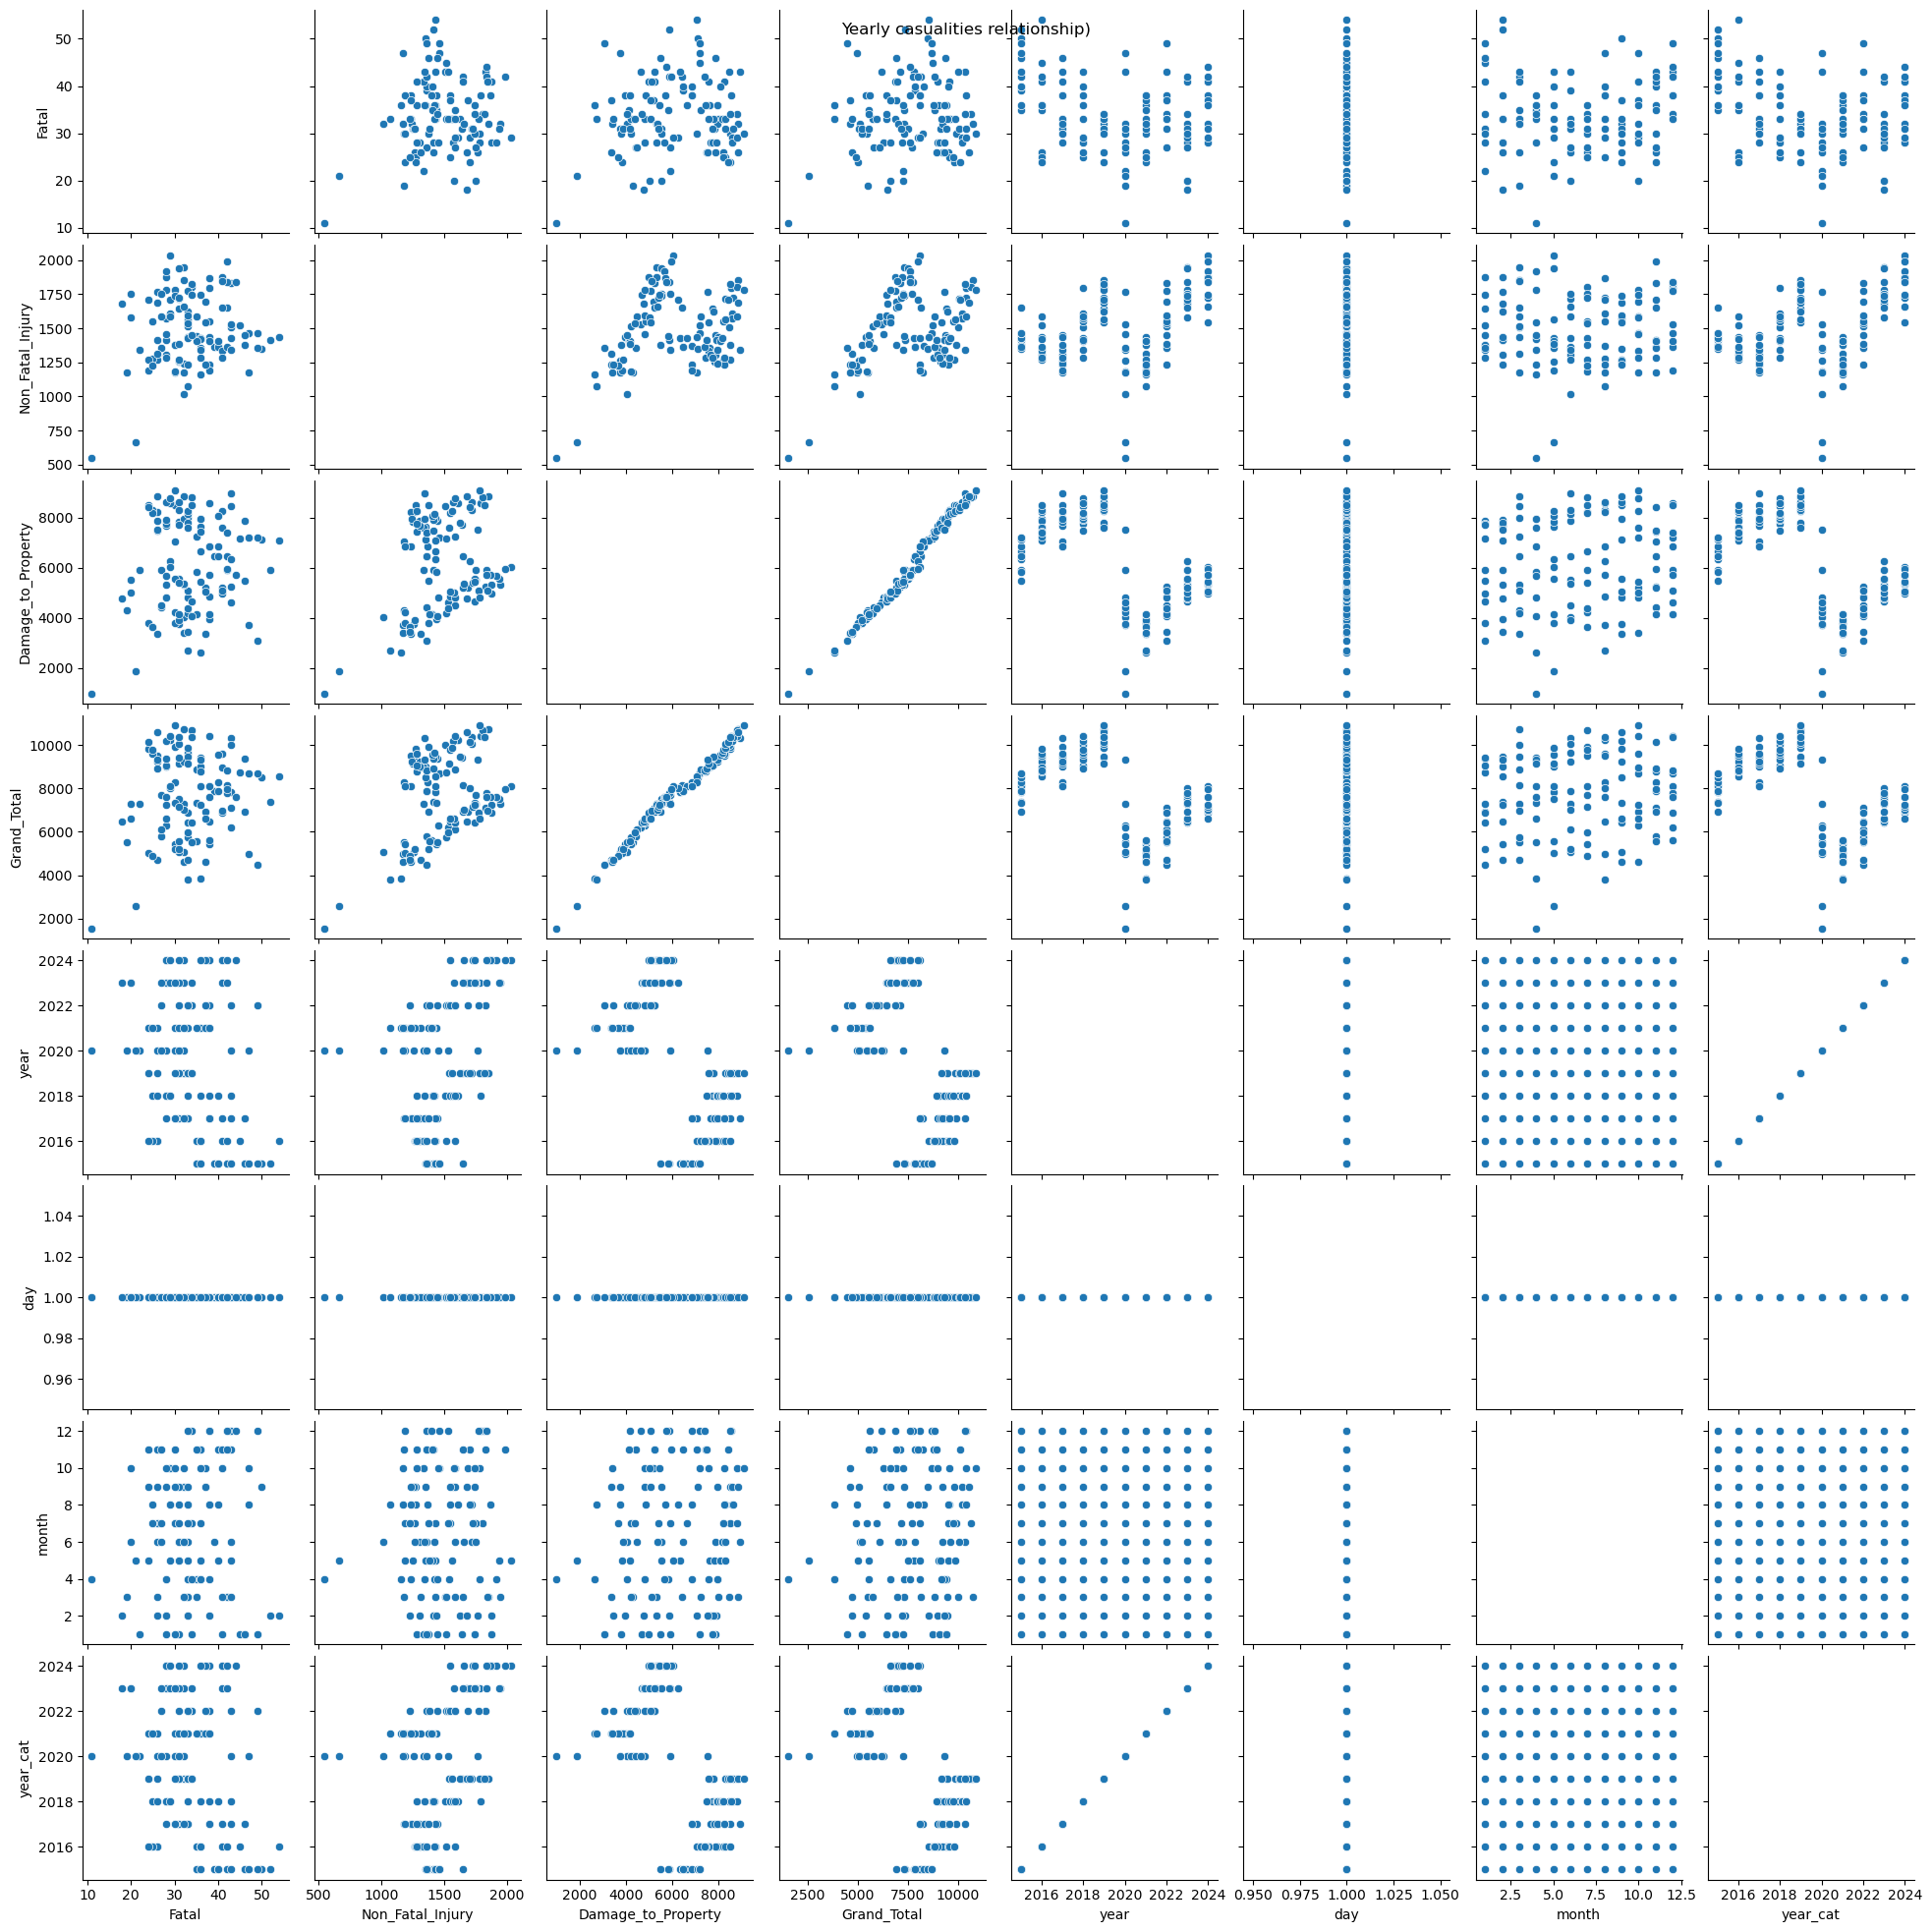

In [21]:
sns.pairplot(mnth_df[['Month', 'Fatal', 'Non_Fatal_Injury', 'Damage_to_Property',
       'Grand_Total', 'year', 'day', 'month', 'date', 'year_cat']], diag_kind = 'scatter')
plt.suptitle('Yearly casualities relationship)')
plt.savefig('Yearly casualities relationship.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
mnth_df.to_csv('mnth_df.csv', index=False)